# Week 06 · PCA & Image Compression (Lossless)
**Course:** Computer Vision (BCSE2022)
**Instructor:** Bùi Huy Kiên
**Prepared:** 2026-07-15


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Hiểu nguyên lý Phân tích thành phần chính (PCA): trung bình, hiệp phương sai, trị riêng / vector riêng.
- Áp dụng PCA lên ảnh đa phổ (multispectral) để giảm chiều dữ liệu và khử tương quan giữa các band.
- Hiểu xấp xỉ hạng thấp (low-rank / SVD) như một cách "nén" ảnh và đánh giá sai số tái tạo.
- Nắm khái niệm entropy — giới hạn dưới của nén không mất mát.
- Cài đặt và đánh giá hai kỹ thuật nén không mất mát: mã hóa Huffman và Run-Length Encoding (RLE).


**Hướng dẫn:**
- Ảnh dùng trong ví dụ và bài tập đã được copy sẵn vào thư mục `input/` của tuần này (trích từ bộ ảnh sách Gonzalez & Woods, DIP 3rd ed. — bộ đầy đủ nằm ở `Gonzalez_images/` gốc repo).
- Mỗi cell hiển thị ảnh dùng `matplotlib`.
- Sử dụng các thư viện: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


Ma trận hiệp phương sai:
 [[3.884 2.338]
 [2.338 1.745]]
Trị riêng (phương sai theo từng trục chính): [5.385 0.243]
Tỷ lệ phương sai giải thích bởi PC1: 95.7%


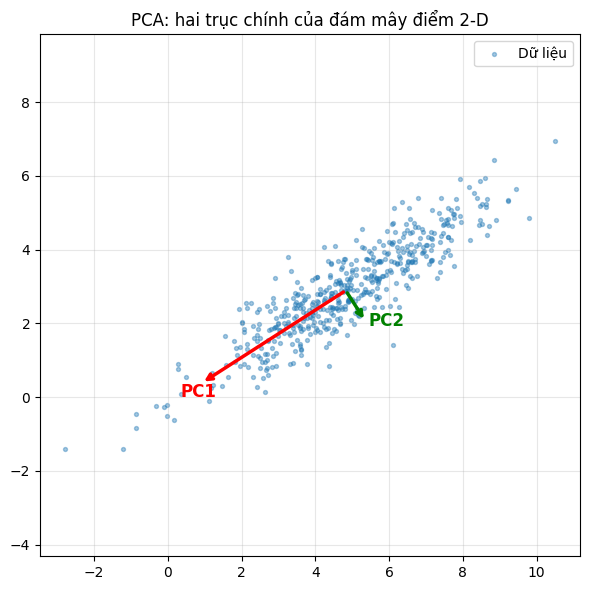

In [1]:
## Ví dụ 1: PCA trực quan trên dữ liệu 2 chiều
# PCA tìm các trục trực giao theo hướng phương sai lớn nhất của dữ liệu.
# Trục PC1 = hướng "trải dài" nhất; PC2 vuông góc với PC1.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
# Tạo đám mây điểm 2D có tương quan
X = rng.normal(size=(500, 2)) @ np.array([[2.0, 1.2], [0.0, 0.6]]) + np.array([5, 3])

mean = X.mean(axis=0)
Xc = X - mean
C = np.cov(Xc.T)                        # ma trận hiệp phương sai 2x2
eigvals, eigvecs = np.linalg.eigh(C)    # trị riêng tăng dần
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("Ma trận hiệp phương sai:\n", C.round(3))
print("Trị riêng (phương sai theo từng trục chính):", eigvals.round(3))
print("Tỷ lệ phương sai giải thích bởi PC1: %.1f%%" % (100 * eigvals[0] / eigvals.sum()))

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.4, label="Dữ liệu")
for i, (val, color) in enumerate(zip(eigvals, ["red", "green"])):
    v = eigvecs[:, i] * 2 * np.sqrt(val)   # vẽ dài 2 độ lệch chuẩn
    plt.annotate("", xy=mean + v, xytext=mean,
                 arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    plt.text(*(mean + v * 1.15), f"PC{i+1}", color=color, fontsize=12, weight="bold")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend()
plt.title("PCA: hai trục chính của đám mây điểm 2-D")
plt.tight_layout()
plt.show()


Trị riêng: [10344.3  2965.9  1400.6   203.5    94.3    31. ]
Tỷ lệ phương sai tích lũy (%): [ 68.78  88.5   97.81  99.17  99.79 100.  ]


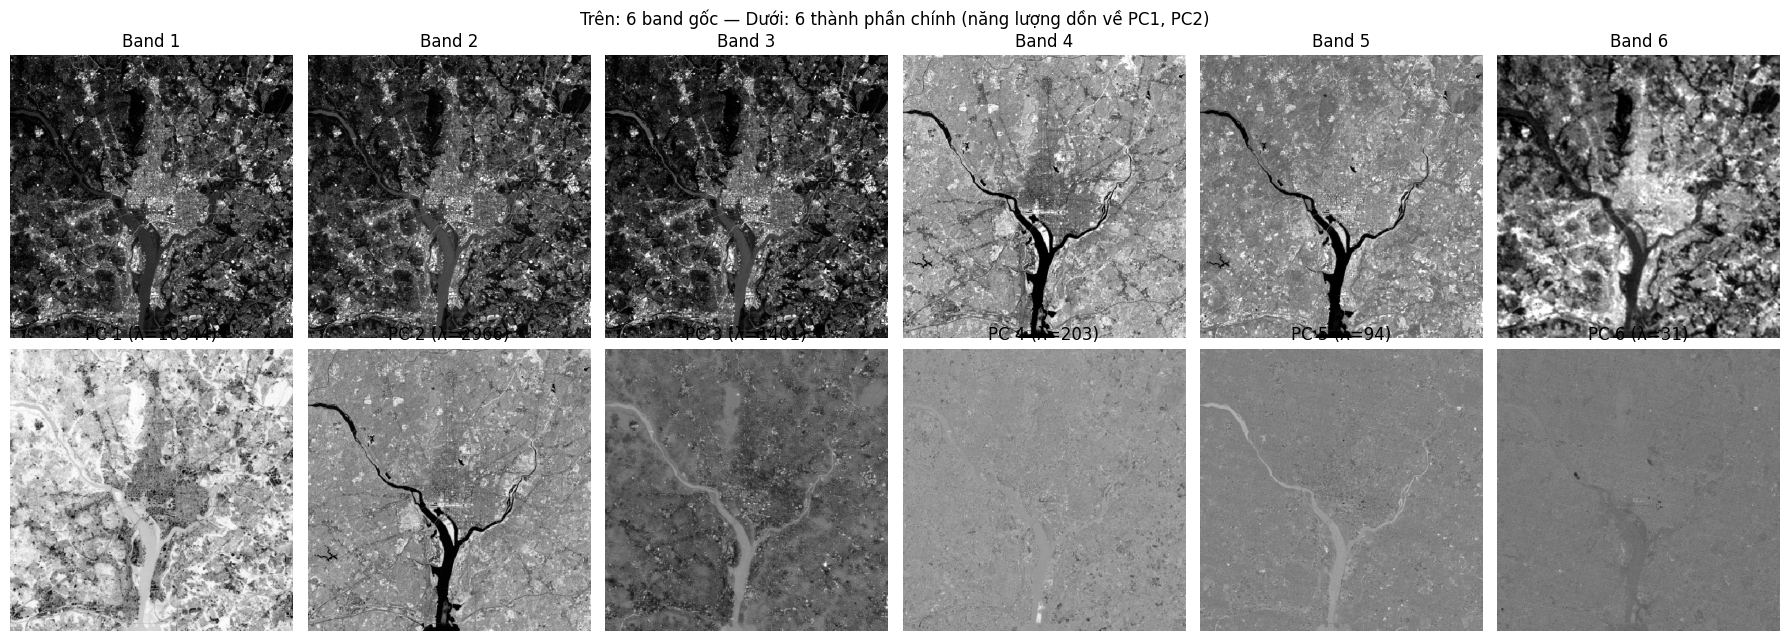

In [2]:
## Ví dụ 2: PCA trên ảnh vệ tinh đa phổ 6 band (Washington DC)
# Ví dụ kinh điển Gonzalez Fig 11.38: 6 band ảnh LANDSAT của cùng một khu vực.
# Mỗi pixel là một vector 6 chiều -> PCA khử tương quan giữa các band.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

band_files = [f"input/Fig1138({c})(WashingtonDC_Band{i}_564).tif"
              for c, i in zip("abcdef", range(1, 7))]
bands = [np.asarray(Image.open(f).convert("L"), dtype=np.float64) for f in band_files]
h, w = bands[0].shape

# Xếp dữ liệu: mỗi hàng là 1 pixel, mỗi cột là 1 band -> ma trận (h*w, 6)
X = np.stack([b.ravel() for b in bands], axis=1)
mean = X.mean(axis=0)
Xc = X - mean
C = np.cov(Xc.T)                               # hiệp phương sai 6x6
eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

Y = Xc @ eigvecs                               # ảnh thành phần chính (h*w, 6)

print("Trị riêng:", eigvals.round(1))
print("Tỷ lệ phương sai tích lũy (%):", (100 * np.cumsum(eigvals) / eigvals.sum()).round(2))

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for i in range(6):
    axes[0, i].imshow(bands[i], cmap="gray")
    axes[0, i].set_title(f"Band {i+1}"); axes[0, i].axis("off")
    pc = Y[:, i].reshape(h, w)
    axes[1, i].imshow(pc, cmap="gray")
    axes[1, i].set_title(f"PC {i+1} (λ={eigvals[i]:.0f})"); axes[1, i].axis("off")
plt.suptitle("Trên: 6 band gốc — Dưới: 6 thành phần chính (năng lượng dồn về PC1, PC2)")
plt.tight_layout()
plt.show()


Giữ k=2/6 thành phần, phương sai giữ được: 88.50%
RMSE từng band: [12.27 12.63 13.17  8.29 10.82 32.56]


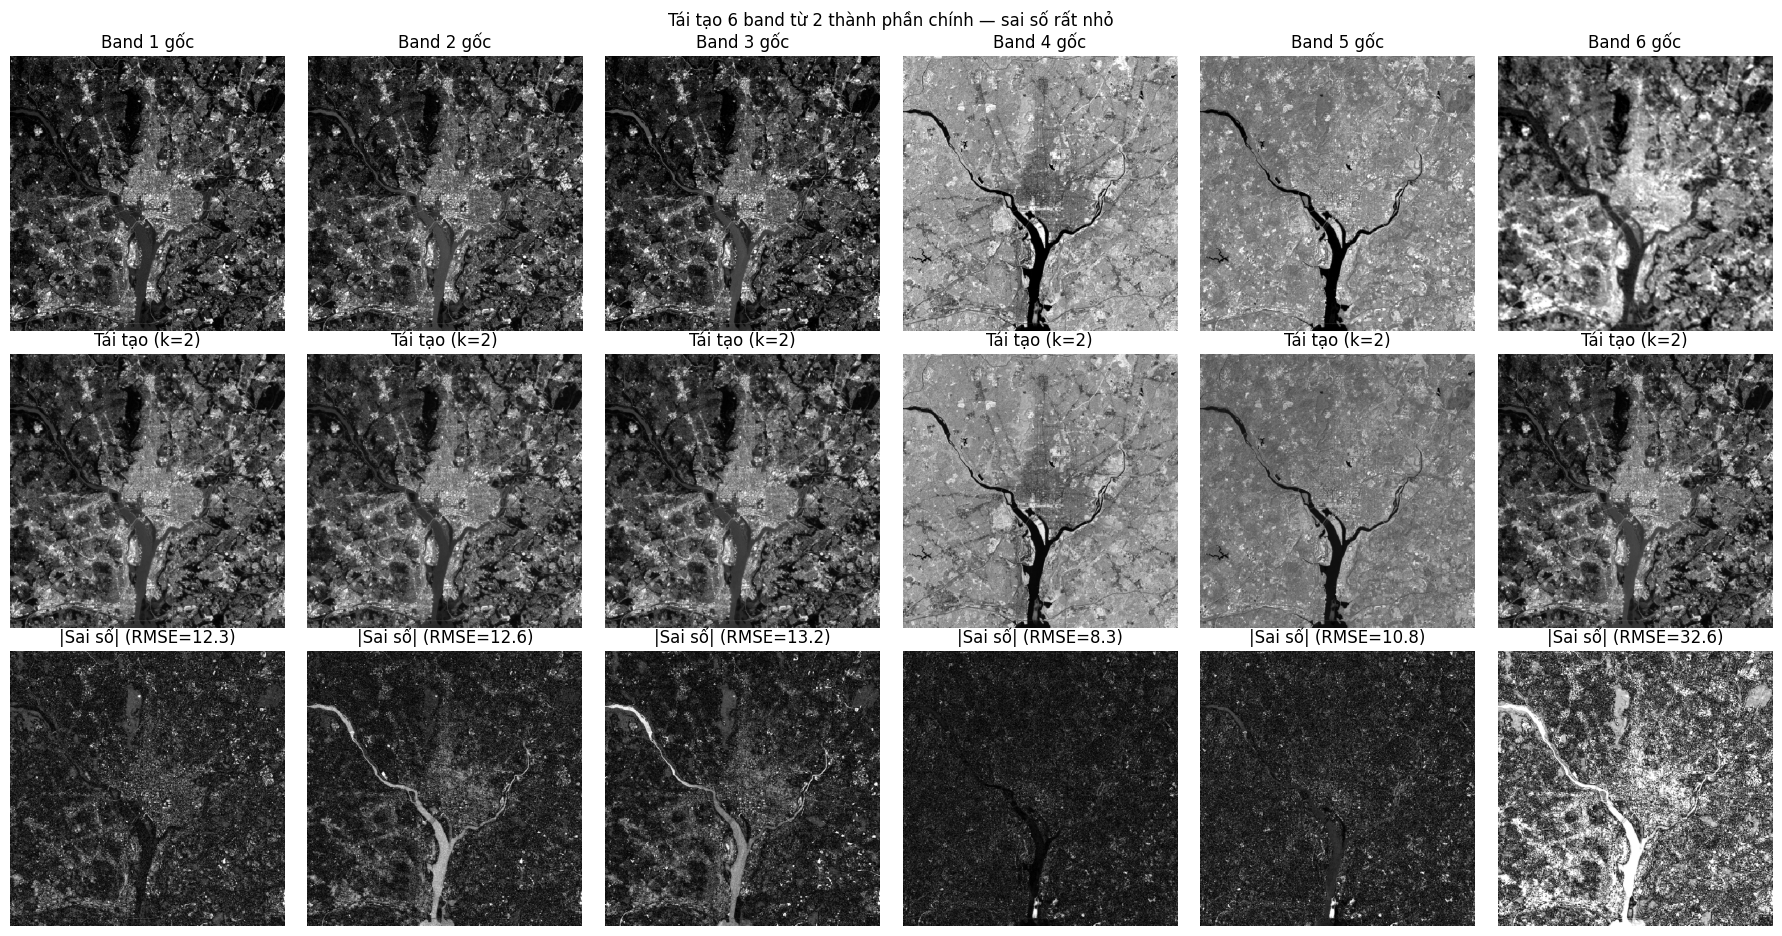

In [3]:
## Ví dụ 3: Tái tạo ảnh đa phổ từ 2 thành phần chính
# Giữ k = 2 / 6 thành phần -> giảm 3 lần dung lượng mà vẫn giữ ~99% phương sai.
# Quan sát ảnh sai số (difference) giữa band gốc và band tái tạo.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

band_files = [f"input/Fig1138({c})(WashingtonDC_Band{i}_564).tif"
              for c, i in zip("abcdef", range(1, 7))]
bands = [np.asarray(Image.open(f).convert("L"), dtype=np.float64) for f in band_files]
h, w = bands[0].shape
X = np.stack([b.ravel() for b in bands], axis=1)
mean = X.mean(axis=0)
Xc = X - mean
eigvals, eigvecs = np.linalg.eigh(np.cov(Xc.T))
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

k = 2
A_k = eigvecs[:, :k]                    # 6 x k
X_hat = (Xc @ A_k) @ A_k.T + mean       # tái tạo từ k thành phần

rmse = np.sqrt(np.mean((X - X_hat) ** 2, axis=0))
print(f"Giữ k={k}/6 thành phần, phương sai giữ được: "
      f"{100 * eigvals[:k].sum() / eigvals.sum():.2f}%")
print("RMSE từng band:", rmse.round(2))

fig, axes = plt.subplots(3, 6, figsize=(18, 9.5))
for i in range(6):
    recon = X_hat[:, i].reshape(h, w)
    diff = np.abs(bands[i] - recon)
    axes[0, i].imshow(bands[i], cmap="gray"); axes[0, i].set_title(f"Band {i+1} gốc")
    axes[1, i].imshow(recon, cmap="gray");    axes[1, i].set_title(f"Tái tạo (k={k})")
    axes[2, i].imshow(diff, cmap="gray", vmin=0, vmax=50); axes[2, i].set_title(f"|Sai số| (RMSE={rmse[i]:.1f})")
    for r in range(3): axes[r, i].axis("off")
plt.suptitle("Tái tạo 6 band từ 2 thành phần chính — sai số rất nhỏ")
plt.tight_layout()
plt.show()


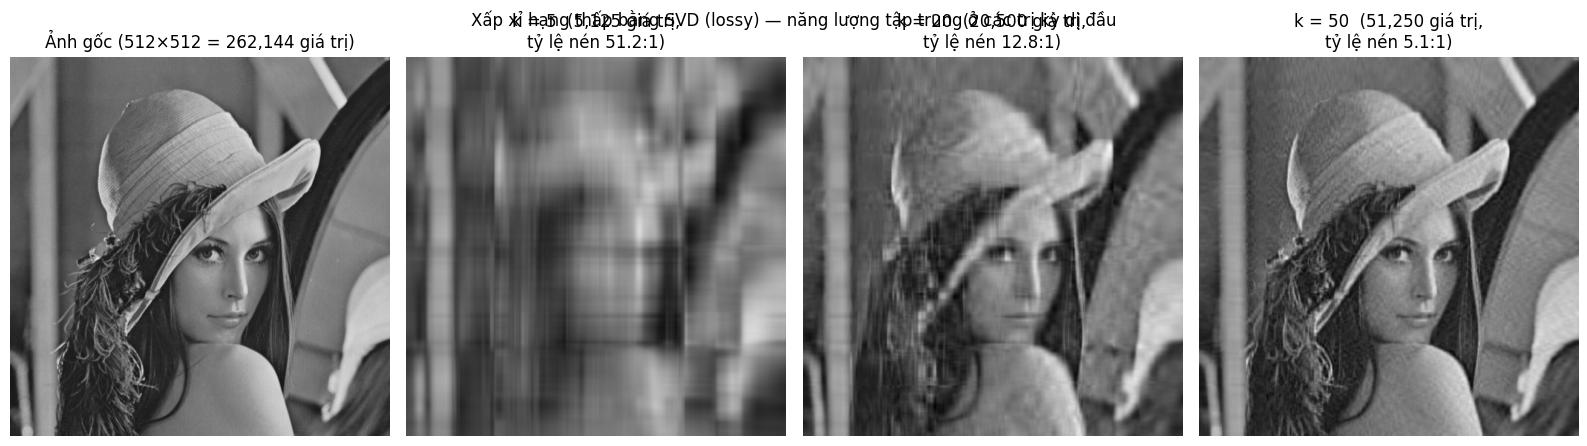

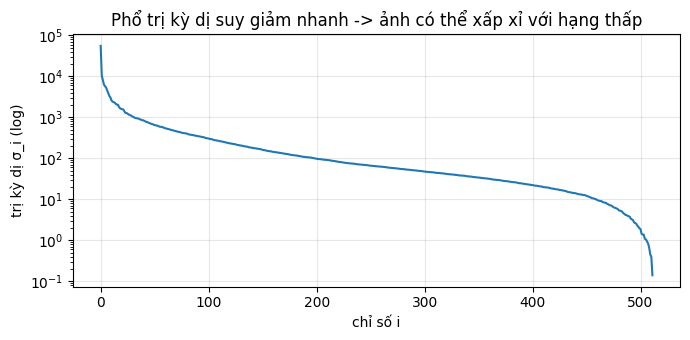

In [4]:
## Ví dụ 4: Xấp xỉ hạng thấp bằng SVD — góc nhìn "nén" một ảnh xám
# Ảnh A (m×n) ≈ tổng k thành phần hạng 1: A_k = Σ σ_i · u_i · v_iᵀ.
# Lưu A_k chỉ cần k(m+n+1) giá trị thay vì m·n.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("input/Fig0809(a).tif").convert("L"), dtype=np.float64)
m, n = img.shape
U, S, Vt = np.linalg.svd(img, full_matrices=False)

ks = [5, 20, 50]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(16, 4.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Ảnh gốc ({m}×{n} = {m*n:,} giá trị)"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    A_k = (U[:, :k] * S[:k]) @ Vt[:k]
    stored = k * (m + n + 1)
    ax.imshow(np.clip(A_k, 0, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"k = {k}  ({stored:,} giá trị,\ntỷ lệ nén {m*n/stored:.1f}:1)")
    ax.axis("off")
plt.suptitle("Xấp xỉ hạng thấp bằng SVD (lossy) — năng lượng tập trung ở các trị kỳ dị đầu")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.semilogy(S)
plt.xlabel("chỉ số i"); plt.ylabel("trị kỳ dị σ_i (log)")
plt.title("Phổ trị kỳ dị suy giảm nhanh -> ảnh có thể xấp xỉ với hạng thấp")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


Entropy của ảnh          : 7.384 bit/pixel
Độ dài mã Huffman trung bình: 7.414 bit/pixel
Mã hóa cố định (uint8)   : 8.000 bit/pixel
Tỷ lệ nén Huffman ≈ 1.08 : 1  (không mất thông tin)


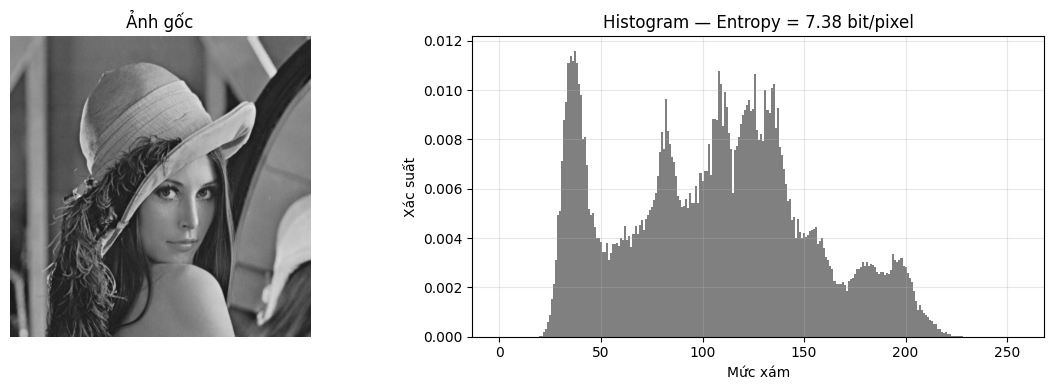

In [5]:
## Ví dụ 5: Nén không mất mát — Entropy và mã hóa Huffman
# Entropy H = -Σ p·log2(p) là số bit/pixel TỐI THIỂU về trung bình.
# Huffman gán mã ngắn cho mức xám xuất hiện nhiều -> tiệm cận entropy.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import heapq

img = np.asarray(Image.open("input/Fig0809(a).tif").convert("L"))

# --- Entropy ---
hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
p = hist / hist.sum()
nz = p > 0
entropy = -np.sum(p[nz] * np.log2(p[nz]))

# --- Mã Huffman ---
def huffman_code_lengths(prob):
    """Trả về độ dài mã Huffman cho từng ký hiệu có xác suất > 0."""
    heap = [(pr, i, {sym: 0}) for i, (sym, pr) in enumerate(
            [(s, pr) for s, pr in enumerate(prob) if pr > 0])]
    heapq.heapify(heap)
    counter = len(heap)
    while len(heap) > 1:
        p1, _, d1 = heapq.heappop(heap)
        p2, _, d2 = heapq.heappop(heap)
        merged = {s: l + 1 for s, l in d1.items()}
        merged.update({s: l + 1 for s, l in d2.items()})
        heapq.heappush(heap, (p1 + p2, counter, merged))
        counter += 1
    return heap[0][2]

lengths = huffman_code_lengths(p)
avg_len = sum(p[s] * l for s, l in lengths.items())

print(f"Entropy của ảnh          : {entropy:.3f} bit/pixel")
print(f"Độ dài mã Huffman trung bình: {avg_len:.3f} bit/pixel")
print(f"Mã hóa cố định (uint8)   : 8.000 bit/pixel")
print(f"Tỷ lệ nén Huffman ≈ {8/avg_len:.2f} : 1  (không mất thông tin)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Ảnh gốc"); axes[0].axis("off")
axes[1].bar(np.arange(256), p, width=1.0, color="gray")
axes[1].set_title(f"Histogram — Entropy = {entropy:.2f} bit/pixel")
axes[1].set_xlabel("Mức xám"); axes[1].set_ylabel("Xác suất"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


Kích thước ảnh nhị phân : (688, 688), 473,344 bit (1 bit/pixel)
Tổng số run             : 13,198  ->  211,168 bit (16 bit/run)
Tỷ lệ nén RLE ≈ 2.24 : 1
Giải mã trùng khớp ảnh gốc: True


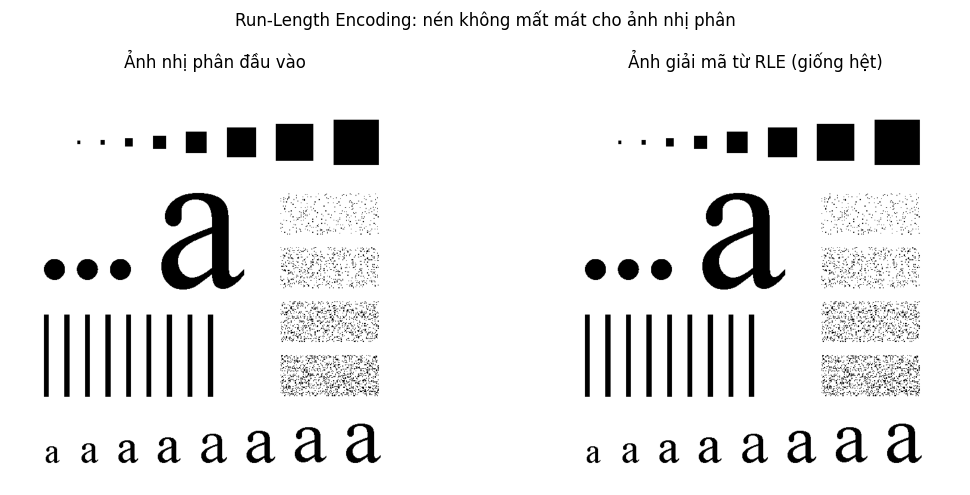

In [6]:
## Ví dụ 6: Run-Length Encoding (RLE) trên ảnh nhị phân
# RLE lưu (giá trị, độ dài loạt) — rất hiệu quả khi ảnh có nhiều vùng đồng nhất
# (tài liệu scan, bản vẽ, mask nhị phân...).

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("input/Fig0441(a)(characters_test_pattern).tif").convert("L"))
binary = (img > 128).astype(np.uint8)

def rle_encode(row):
    """Mã hóa 1 hàng nhị phân thành danh sách (giá trị, độ dài)."""
    runs = []
    val, count = row[0], 1
    for x in row[1:]:
        if x == val:
            count += 1
        else:
            runs.append((val, count)); val, count = x, 1
    runs.append((val, count))
    return runs

def rle_decode(runs):
    return np.concatenate([np.full(c, v, dtype=np.uint8) for v, c in runs])

all_runs = [rle_encode(r) for r in binary]
n_runs = sum(len(r) for r in all_runs)

# Giả sử mỗi run lưu bằng 16 bit (1 bit giá trị + 15 bit độ dài)
raw_bits = binary.size          # 1 bit/pixel cho ảnh nhị phân
rle_bits = n_runs * 16
print(f"Kích thước ảnh nhị phân : {binary.shape}, {raw_bits:,} bit (1 bit/pixel)")
print(f"Tổng số run             : {n_runs:,}  ->  {rle_bits:,} bit (16 bit/run)")
print(f"Tỷ lệ nén RLE ≈ {raw_bits/rle_bits:.2f} : 1")

# Kiểm chứng lossless: giải mã và so sánh
decoded = np.stack([rle_decode(r) for r in all_runs])
print("Giải mã trùng khớp ảnh gốc:", bool(np.array_equal(decoded, binary)))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(binary, cmap="gray"); axes[0].set_title("Ảnh nhị phân đầu vào"); axes[0].axis("off")
axes[1].imshow(decoded, cmap="gray"); axes[1].set_title("Ảnh giải mã từ RLE (giống hệt)"); axes[1].axis("off")
plt.suptitle("Run-Length Encoding: nén không mất mát cho ảnh nhị phân")
plt.tight_layout(); plt.show()


## 📝 Exercises (en)
1. Repeat Example 2–3 keeping k = 1 and k = 3 principal components. Plot RMSE per band as a function of k.
2. Apply SVD low-rank approximation to `input/Fig0459(a)(orig_chest_xray).tif`. Find the smallest k such that PSNR ≥ 35 dB.
3. Compute the entropy of the *difference image* d(x,y) = f(x,y) − f(x,y−1) (previous-pixel predictor) and compare with the entropy of the original image. Explain why predictive coding helps.
4. Extend the RLE example to 8-bit grayscale images using bit-plane decomposition (Week 02): apply RLE to each bit plane and report the total compression ratio, with and without Gray code.
5. (Optional) Implement full Huffman encoding/decoding (not just code lengths) and verify the decoded image is identical to the input.

## 📝 Bài tập (vi)
1. Lặp lại Ví dụ 2–3 với k = 1 và k = 3 thành phần chính. Vẽ đồ thị RMSE từng band theo k.
2. Áp dụng xấp xỉ SVD hạng thấp cho `input/Fig0459(a)(orig_chest_xray).tif`. Tìm k nhỏ nhất sao cho PSNR ≥ 35 dB.
3. Tính entropy của *ảnh hiệu* d(x,y) = f(x,y) − f(x,y−1) (dự đoán bằng pixel liền trước) và so sánh với entropy ảnh gốc. Giải thích vì sao mã hóa dự đoán giúp nén tốt hơn.
4. Mở rộng ví dụ RLE cho ảnh xám 8-bit bằng phân tách bit-plane (tuần 02): áp dụng RLE cho từng bit plane, báo cáo tỷ lệ nén tổng, có và không dùng mã Gray.
5. (Tuỳ chọn) Cài đặt đầy đủ mã hóa/giải mã Huffman (không chỉ độ dài mã) và kiểm chứng ảnh giải mã giống hệt ảnh gốc.